In [1]:
import torch

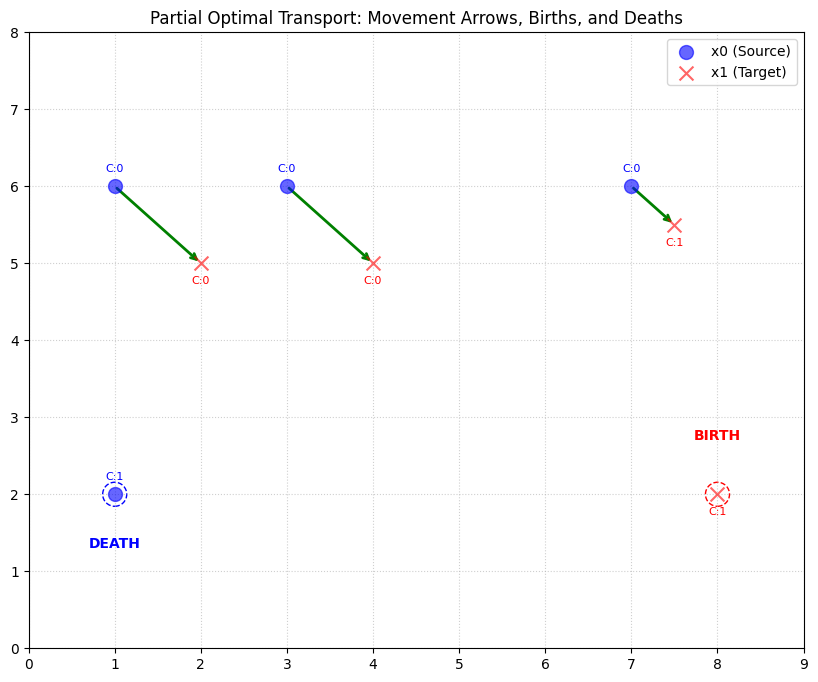

In [4]:
from chemflow.flow_matching.assignment import distance_and_class_based_assignment
import numpy as np
import matplotlib.pyplot as plt


# --- Visual Test Function with Arrows ---
def test_visual_assignment_with_arrows():
    # 1. Setup Synthetic Data
    # x0: Previous Frame (Sources)
    valid_x0 = np.array(
        [
            [1, 6],  # Match 1: Moves down-right
            [3, 6],  # Match 2: Moves down-right
            [1, 2],  # Death: Too far from everything
            [7, 6],  # Class Mismatch: Close to x1[3] but different class
        ]
    )
    class_x0 = np.array([0, 0, 1, 0])

    # x1: Current Frame (Targets)
    valid_x1 = np.array(
        [
            [2, 5],  # Match 1 target
            [4, 5],  # Match 2 target
            [8, 2],  # Birth: New point far away
            [7.5, 5.5],  # Class Mismatch target (class 1)
        ]
    )
    class_x1 = np.array([0, 0, 1, 1])

    # 2. Run your assignment function
    # Using high C_class to force class consistency
    row_ind, col_ind = distance_and_class_based_assignment(
        valid_x0, valid_x1, class_x0, class_x1, C_dist=1.0, C_class=0.0, C_birth=2.0
    )

    # 3. Visualization
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot all points first
    ax.scatter(
        valid_x0[:, 0],
        valid_x0[:, 1],
        c="blue",
        s=100,
        label="x0 (Source)",
        marker="o",
        alpha=0.6,
        zorder=2,
    )
    ax.scatter(
        valid_x1[:, 0],
        valid_x1[:, 1],
        c="red",
        s=100,
        label="x1 (Target)",
        marker="x",
        alpha=0.6,
        zorder=2,
    )

    # Annotate classes
    for i, txt in enumerate(class_x0):
        ax.annotate(
            f"C:{txt}",
            (valid_x0[i, 0], valid_x0[i, 1]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            color="blue",
            fontsize=8,
        )
    for i, txt in enumerate(class_x1):
        ax.annotate(
            f"C:{txt}",
            (valid_x1[i, 0], valid_x1[i, 1]),
            textcoords="offset points",
            xytext=(0, -15),
            ha="center",
            color="red",
            fontsize=8,
        )

    # Draw Arrows for Matches
    matched_x0_indices = set()
    matched_x1_indices = set()

    for r, c in zip(row_ind, col_ind):
        p0 = valid_x0[r]
        p1 = valid_x1[c]

        # Use annotate for a nice arrow
        ax.annotate(
            "",
            xy=(p1[0], p1[1]),
            xycoords="data",
            xytext=(p0[0], p0[1]),
            textcoords="data",
            arrowprops=dict(arrowstyle="->", color="green", lw=2, ls="-"),
            zorder=1,
        )

        matched_x0_indices.add(r)
        matched_x1_indices.add(c)

    # Highlight Deaths (Unmatched x0)
    deaths = [i for i in range(len(valid_x0)) if i not in matched_x0_indices]
    for d in deaths:
        ax.scatter(
            valid_x0[d, 0],
            valid_x0[d, 1],
            s=300,
            facecolors="none",
            edgecolors="blue",
            linestyle="--",
        )
        ax.text(
            valid_x0[d, 0],
            valid_x0[d, 1] - 0.7,
            "DEATH",
            color="blue",
            ha="center",
            weight="bold",
        )

    # Highlight Births (Unmatched x1)
    births = [i for i in range(len(valid_x1)) if i not in matched_x1_indices]
    for b in births:
        ax.scatter(
            valid_x1[b, 0],
            valid_x1[b, 1],
            s=300,
            facecolors="none",
            edgecolors="red",
            linestyle="--",
        )
        ax.text(
            valid_x1[b, 0],
            valid_x1[b, 1] + 0.7,
            "BIRTH",
            color="red",
            ha="center",
            weight="bold",
        )

    ax.set_title("Partial Optimal Transport: Movement Arrows, Births, and Deaths")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 8)
    plt.show()


# Run the test
test_visual_assignment_with_arrows()

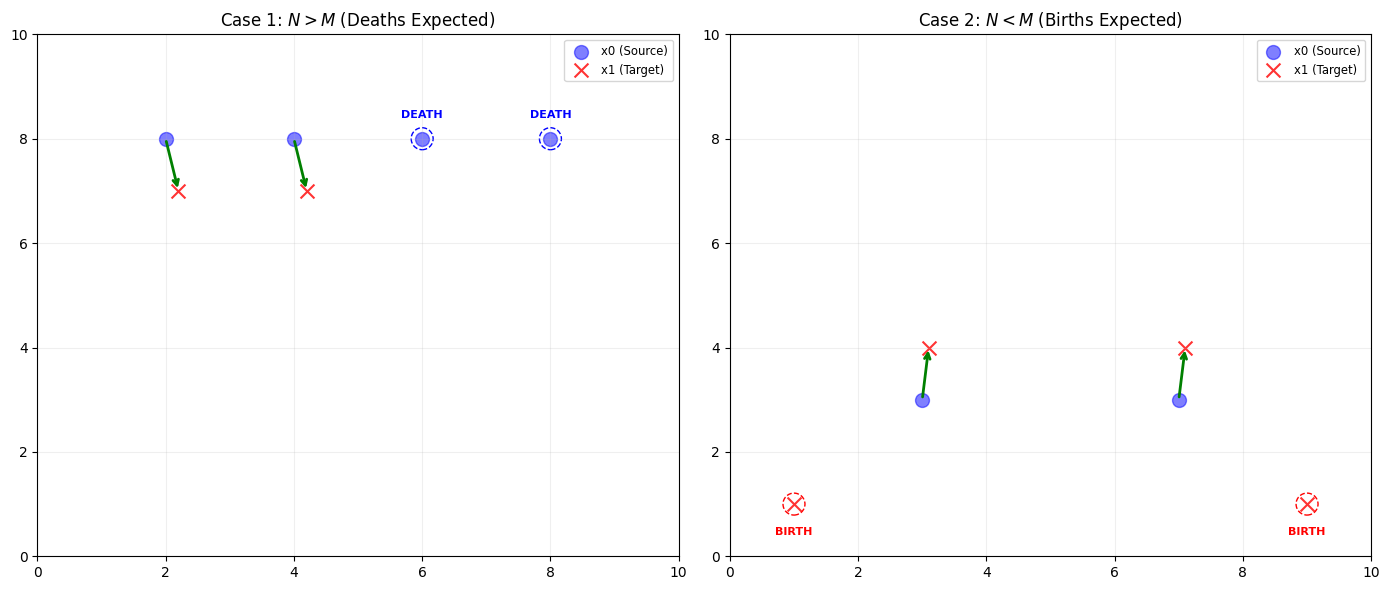

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment


def run_scenario(ax, x0, x1, c0, c1, title, C_birth=5.0):
    # Run the corrected function
    row_ind, col_ind = distance_and_class_based_assignment(
        x0, x1, c0, c1, C_dist=1.0, C_class=10.0, C_birth=C_birth
    )

    # Plot points
    ax.scatter(x0[:, 0], x0[:, 1], c="blue", s=100, label="x0 (Source)", alpha=0.5)
    ax.scatter(
        x1[:, 0], x1[:, 1], c="red", marker="x", s=100, label="x1 (Target)", alpha=0.8
    )

    # Draw Matches (Arrows)
    matched_x0, matched_x1 = set(row_ind), set(col_ind)
    for r, c in zip(row_ind, col_ind):
        ax.annotate(
            "",
            xy=x1[c],
            xytext=x0[r],
            arrowprops=dict(arrowstyle="->", color="green", lw=2),
        )

    # Highlight Deaths (Blue circles)
    for i in range(len(x0)):
        if i not in matched_x0:
            ax.scatter(
                x0[i, 0], x0[i, 1], s=250, edgecolors="blue", facecolors="none", ls="--"
            )
            ax.text(
                x0[i, 0],
                x0[i, 1] + 0.4,
                "DEATH",
                color="blue",
                ha="center",
                fontsize=8,
                weight="bold",
            )

    # Highlight Births (Red circles)
    for i in range(len(x1)):
        if i not in matched_x1:
            ax.scatter(
                x1[i, 0], x1[i, 1], s=250, edgecolors="red", facecolors="none", ls="--"
            )
            ax.text(
                x1[i, 0],
                x1[i, 1] - 0.6,
                "BIRTH",
                color="red",
                ha="center",
                fontsize=8,
                weight="bold",
            )

    ax.set_title(title)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.grid(True, alpha=0.2)
    ax.legend(loc="upper right", fontsize="small")


# --- Generate Scenarios ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Case 1: More nodes in x0 (N=4, M=2) -> Points should "Die"
x0_1 = np.array([[2, 8], [4, 8], [6, 8], [8, 8]])
c0_1 = np.zeros(4)
x1_1 = np.array([[2.2, 7], [4.2, 7]])  # Only two targets available
c1_1 = np.zeros(2)
run_scenario(ax1, x0_1, x1_1, c0_1, c1_1, "Case 1: $N > M$ (Deaths Expected)")

# Case 2: More nodes in x1 (N=2, M=4) -> Points should be "Born"
x0_2 = np.array([[3, 3], [7, 3]])
c0_2 = np.zeros(2)
x1_2 = np.array(
    [[3.1, 4], [7.1, 4], [1, 1], [9, 1]]
)  # Two existing matches, two new points
c1_2 = np.zeros(4)
run_scenario(ax2, x0_2, x1_2, c0_2, c1_2, "Case 2: $N < M$ (Births Expected)")

plt.tight_layout()
plt.show()


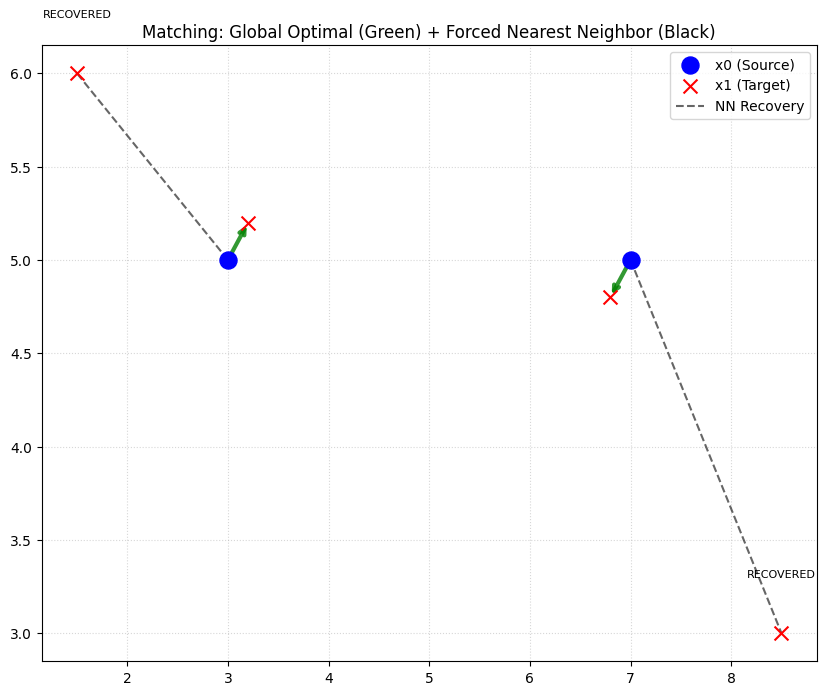

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def test_forced_nearest_neighbor_matching():
    # --- 1. Setup Data ---
    # x0 has 2 nodes
    valid_x0 = np.array([[3, 5], [7, 5]])
    class_x0 = np.array([0, 1])

    # x1 has 4 nodes (2 will match in Pass 1, 2 are "orphans")
    valid_x1 = np.array(
        [
            [3.2, 5.2],  # Close to x0[0] -> Match Pass 1
            [6.8, 4.8],  # Close to x0[1] -> Match Pass 1
            [1.5, 6.0],  # Far, but closer to x0[0] -> Orphan
            [8.5, 3.0],  # Far, but closer to x0[1] -> Orphan
        ]
    )
    class_x1 = np.array([0, 1, 0, 1])

    # Parameters
    C_birth = 2.0  # Strict threshold to ensure orphans exist

    # --- 2. Pass 1: Global Partial Optimal Transport ---
    row_ind1, col_ind1 = distance_and_class_based_assignment(
        valid_x0, valid_x1, class_x0, class_x1, C_birth=C_birth
    )

    # Identify orphans in x1
    matched_x1_indices = set(col_ind1)
    orphan_x1_indices = [i for i in range(len(valid_x1)) if i not in matched_x1_indices]

    # --- 3. Pass 2: Nearest Neighbor for Orphans ---
    # We find the closest x0 for every x1 orphan
    pass2_assignments = []
    for ox1 in orphan_x1_indices:
        # Calculate distance from this orphan to ALL x0
        distances = np.linalg.norm(valid_x0 - valid_x1[ox1], axis=1)
        closest_x0_idx = np.argmin(distances)
        pass2_assignments.append((closest_x0_idx, ox1))

    # --- 4. Visualization ---
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        valid_x0[:, 0], valid_x0[:, 1], c="blue", s=150, label="x0 (Source)", zorder=5
    )
    ax.scatter(
        valid_x1[:, 0],
        valid_x1[:, 1],
        c="red",
        marker="x",
        s=100,
        label="x1 (Target)",
        zorder=5,
    )

    # Draw Pass 1: Green Arrows (1-to-1 optimal)
    for r, c in zip(row_ind1, col_ind1):
        ax.annotate(
            "",
            xy=valid_x1[c],
            xytext=valid_x0[r],
            arrowprops=dict(arrowstyle="->", color="green", lw=3, alpha=0.8),
        )

    # Draw Pass 2: Black Dashed Lines (Many-to-1 nearest neighbor)
    for r, c in pass2_assignments:
        ax.plot(
            [valid_x0[r][0], valid_x1[c][0]],
            [valid_x0[r][1], valid_x1[c][1]],
            color="black",
            linestyle="--",
            lw=1.5,
            alpha=0.6,
            label="NN Recovery" if (r, c) == pass2_assignments[0] else "",
        )
        # Mark as recovered
        ax.text(
            valid_x1[c][0],
            valid_x1[c][1] + 0.3,
            "RECOVERED",
            color="black",
            ha="center",
            fontsize=8,
        )

    ax.set_title("Matching: Global Optimal (Green) + Forced Nearest Neighbor (Black)")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    plt.show()


# Run the test
test_forced_nearest_neighbor_matching()


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Batch
from scipy.spatial.transform import Rotation as R

from chemflow.dataset.molecule_data import MoleculeData
from chemflow.flow_matching.assignment import partial_optimal_transport


def test_pot_wrapper_visual():
    # 1. Create Synthetic "Sample" (x0) - 3 atoms
    x0 = torch.randn(3, 3)
    a0 = torch.tensor([0, 0, 1])  # Atom types
    c0 = torch.tensor([0, 0, 0])  # Class
    edge_index0 = torch.tensor([[0, 1], [1, 0], [0, 2], [2, 0]], dtype=torch.long)
    e0 = torch.tensor([1, 1, 1, 1], dtype=torch.float)

    # 2. Create Synthetic "Target" (x1) - 5 atoms (Rotated + 2 extra)
    x1_matched = x0 + torch.randn_like(x0)
    x1_orphans = torch.randn(2, 3)  # One near x0[0], one far
    x1 = torch.cat([x1_matched, x1_orphans], dim=0)
    a1 = torch.cat([a0, torch.tensor([0, 1])], dim=0)
    c1 = torch.cat([c0, torch.tensor([0, 1])], dim=0)
    edge_index1 = torch.tensor(
        [[0, 1], [1, 0], [0, 2], [2, 0], [1, 3], [3, 1], [3, 4], [4, 3]],
        dtype=torch.long,
    )
    e1 = torch.tensor([1, 1, 1, 1, 1, 1, 1, 1], dtype=torch.float)

    # Wrap in MoleculeData
    sample_mol = MoleculeData(
        x=x0,
        a=a0,
        c=c0,
        edge_index=edge_index0,
        e=e0,
    )
    target_mol = MoleculeData(
        x=x1,
        a=a1,
        c=c1,
        edge_index=edge_index1,
        e=e1,
    )

    # Mock Batching
    samples_batched = Batch.from_data_list([sample_mol])
    targets_batched = Batch.from_data_list([target_mol])

    # 3. Run the Function
    res = partial_optimal_transport(
        samples_batched,
        targets_batched,
        C_dist=1.0,
        C_class=10.0,
        C_birth=2.0,
        optimal_transport="equivariant",
    )

    m_samples, m_targets, u_samples, u_targets = res
    ms, mt, us, ut = m_samples[0], m_targets[0], u_samples[0], u_targets[0]

    # 4. Visualization
    plt.figure(figsize=(10, 8))

    # Plot Matched (Should be aligned now)
    plt.scatter(ms.x[:, 0], ms.x[:, 1], c="blue", label="Sample (Aligned)", s=100)
    plt.scatter(
        mt.x[:, 0], mt.x[:, 1], c="red", marker="x", label="Target (Matched)", s=100
    )

    # Draw Green Arrows for Global Matches
    for i in range(ms.num_nodes):
        plt.annotate(
            "",
            xy=mt.x[i],
            xytext=ms.x[i],
            arrowprops=dict(arrowstyle="->", color="green", lw=2),
        )

    # Plot Unmatched/Orphans
    if ut.num_nodes > 0:
        plt.scatter(
            ut.x[:, 0],
            ut.x[:, 1],
            c="orange",
            marker="s",
            label="Target (Orphan)",
            s=80,
        )

        # Draw Black Dashed Lines to NEAREST nodes using the new attribute
        # Note: nearest_sample_idx points to indices in the ORIGINAL x0
        x0_orig_aligned = ms.x  # Assuming you saved R/t

        for i in range(ut.num_nodes):
            source_idx = ut.nearest_sample_idx[i]
            p_source = x0_orig_aligned[source_idx]
            p_target = ut.x[i]
            plt.plot(
                [p_source[0], p_target[0]],
                [p_source[1], p_target[1]],
                "k--",
                alpha=0.5,
                label="Nearest Neighbor" if i == 0 else "",
            )

    plt.title("POT: Alignment + Nearest Neighbor Recovery")
    plt.legend()
    plt.axis("equal")
    plt.show()


test_pot_wrapper_visual()

IndexError: The shape of the mask [2] at index 0 does not match the shape of the indexed tensor [4] at index 0

/cluster/project/krause/frankem/chemflow/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating Synthetic Data...
Running Partial Optimal Transport...
(3, 4) (3, 4)
Visualizing...
Result Nodes: 4
Is Aux Sample: tensor([False, False, False,  True])
Is Aux Target: tensor([False, False, False, False])


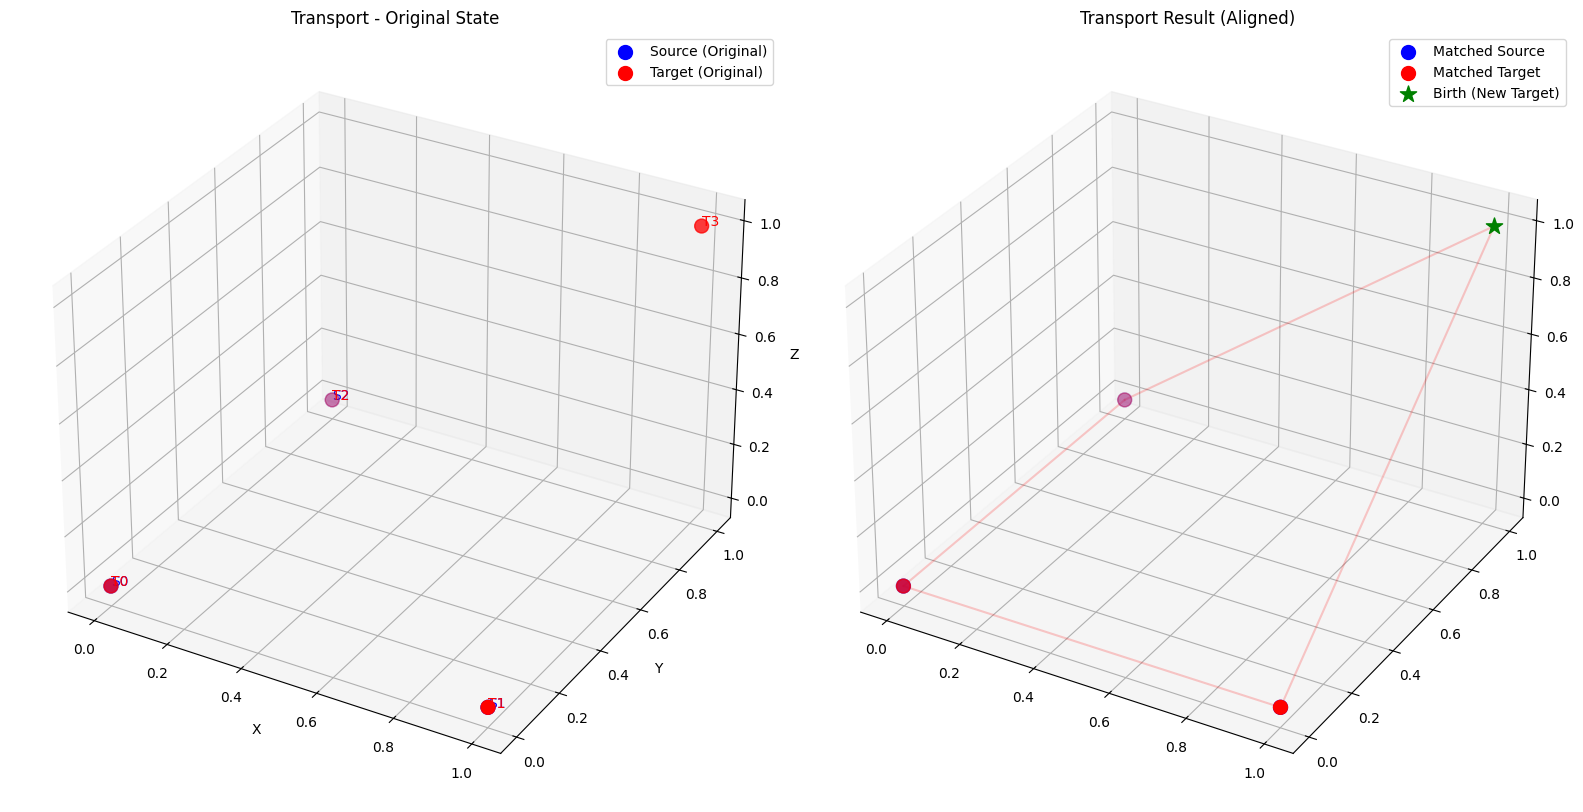

In [1]:
from tests.test_assignment import test_pot_visual

test_pot_visual()